# Plaque–Vessel Spatial Relationship Analysis

This notebook explores the spatial relationship between Aβ plaques and blood vessels
(CD31 staining) using the signed distance transform (SDT) from each plaque surface
to the nearest vessel wall.

**SDT convention (`sdt_CD31`):**
- `< 0` → plaque is *inside* / overlapping the vessel (and the magnitude indicates
  how far the plaque surface reaches into the vessel lumen)
- `= 0` → plaque surface just touches the vessel wall
- `> 0` → plaque is *outside* the vessel; value = distance to nearest vessel (mm)

## Outline
1. Setup & data loading  
2. SDT distribution (ECDF, histogram) by treatment & genotype  
3. Plaque–vessel classification: *inside*, *near*, *far*  
4. Subject-level proximity fractions & boxplots  
5. Two-way ANOVA (treatment × genotype) for proximity fractions  
6. Intravascular plaques: vessel-calibre estimation from SDT  
7. Subject-level vessel-calibre summaries  
8. 2-D spatial maps coloured by vessel-proximity category  

## 1  Setup & data loading

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

warnings.filterwarnings("ignore", category=FutureWarning)

# ── aesthetics ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
TREAT_ORDER   = ["PBS", "Lecanemab"]
TREAT_PALETTE = {"PBS": "#4C72B0", "Lecanemab": "#DD8452"}
GENO_ORDER    = ["ApoE3", "ApoE4"]
GENO_PALETTE  = {"ApoE3": "#55A868", "ApoE4": "#C44E52"}

# ── analysis parameters ───────────────────────────────────────────────────────
VOL_THRESH_ML = 1e-4   # remove implausibly large plaques (same as other notebooks)
TAU_UM        = 5.0    # boundary between "near vessel" and "far from vessel" (µm)

# vessel-diameter bins for intravascular plaques
VESSEL_BINS_UM     = [0, 10, 20, np.inf]
VESSEL_BIN_LABELS  = ["<10 µm", "10–20 µm", ">20 µm"]
DATASET_NAMES = ["early", "late"]


In [2]:
def classify_plaques(plaque_df, tau_um=TAU_UM,
                     vessel_bins_um=VESSEL_BINS_UM,
                     vessel_bin_labels=VESSEL_BIN_LABELS):
    """Add vessel-relation category and min-vessel-diameter estimate."""
    out = plaque_df.copy()

    # three-way proximity label
    out["vessel_relation"] = pd.cut(
        out["sdt_CD31_um"],
        bins=[-np.inf, 0, tau_um, np.inf],
        labels=[
            "inside vessel",
            f"near vessel (0–{tau_um:g} µm)",
            f"far from vessel (>{tau_um:g} µm)",
        ],
        include_lowest=True,
        right=True,
    )

    # minimum vessel diameter estimate for intravascular plaques
    # d_vessel ≥ d_plaque + 2 * |SDT|  (SDT < 0 inside vessel)
    out["min_vessel_diam_um"] = np.nan
    inside = out["sdt_CD31_um"] < 0
    out.loc[inside, "min_vessel_diam_um"] = (
        out.loc[inside, "equiv_diam_um"] - 2 * out.loc[inside, "sdt_CD31_um"]
    )

    # bin estimated minimum vessel diameter
    out["vessel_diam_bin"] = pd.cut(
        out["min_vessel_diam_um"],
        bins=vessel_bins_um,
        labels=vessel_bin_labels,
        include_lowest=True,
        right=False,
    )

    return out


In [3]:
def subject_proximity_fractions(plaque_df,
                                group_cols=("subject", "genotype", "treatment", "sex")):
    """Per-subject fraction of plaques in each vessel-relation class, returned in wide format."""
    counts = (
        plaque_df.groupby(list(group_cols) + ["vessel_relation"], observed=True)
        .size()
        .rename("n")
        .reset_index()
    )
    totals = (
        plaque_df.groupby(list(group_cols), observed=True)
        .size()
        .rename("n_total")
        .reset_index()
    )
    out = counts.merge(totals, on=list(group_cols))
    out["fraction"] = out["n"] / out["n_total"]

    # Pivot to wide format so each category becomes its own frac_* column
    PROX_RENAME = {
        "inside vessel":                              "frac_inside_vessel",
        f"near vessel (0\u2013{TAU_UM:g} \u00b5m)": "frac_near_vessel",
        f"far from vessel (>{TAU_UM:g} \u00b5m)":   "frac_far_vessel",
    }
    wide = (
        out.pivot_table(index=list(group_cols), columns="vessel_relation",
                        values="fraction", fill_value=0.0)
        .rename(columns=PROX_RENAME)
        .reset_index()
    )
    wide.columns.name = None
    return wide


In [4]:
def boxstrip(ax, data, x, y, hue=None, order=None, hue_order=None, palette=None,
             ylabel=None, yscale="linear"):
    """Paired boxplot + stripplot helper (shared with treatment_effect_analysis)."""
    sns.boxplot(data=data, x=x, y=y, hue=hue,
                order=order, hue_order=hue_order, palette=palette,
                fill=False, linewidth=1.2, fliersize=0, ax=ax)
    sns.stripplot(data=data, x=x, y=y, hue=hue,
                  order=order, hue_order=hue_order, palette=palette,
                  dodge=True, alpha=0.7, size=6, jitter=True, ax=ax)
    if yscale != "linear":
        ax.set_yscale(yscale)
    if ylabel:
        ax.set_ylabel(ylabel)
    handles, labels = ax.get_legend_handles_labels()
    n = len(hue_order) if hue_order else 2
    ax.legend(handles[:n], labels[:n], title=hue, fontsize=9)


In [5]:
def run_twoway_anova(data, outcome):
    """Two-way OLS ANOVA: outcome ~ C(treatment) * C(genotype).
    Falls back to one-way (treatment only) when only one genotype is present.
    Returns ANOVA table."""
    n_geno = data["genotype"].nunique()
    if n_geno > 1:
        formula = f"{outcome} ~ C(treatment) * C(genotype)"
    else:
        formula = f"{outcome} ~ C(treatment)"
    model   = ols(formula, data=data).fit()
    return anova_lm(model, typ=2)



=== Dataset: early ===


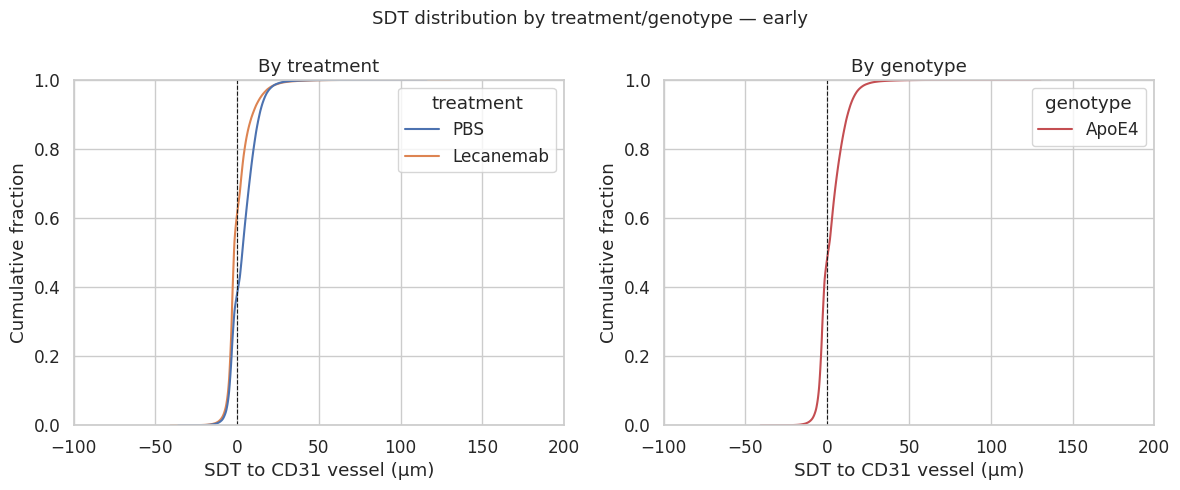

/localscratch/tmp/ipykernel_1540319/1905546179.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(groups, rotation=20, ha="right")


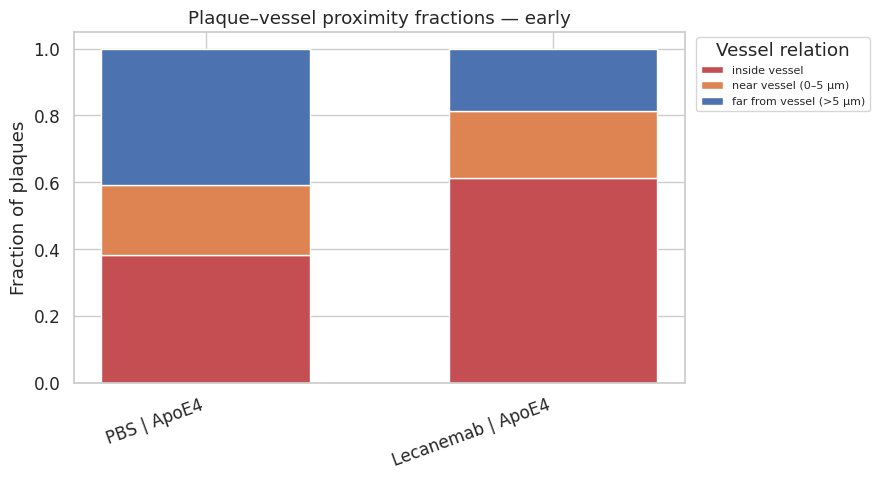

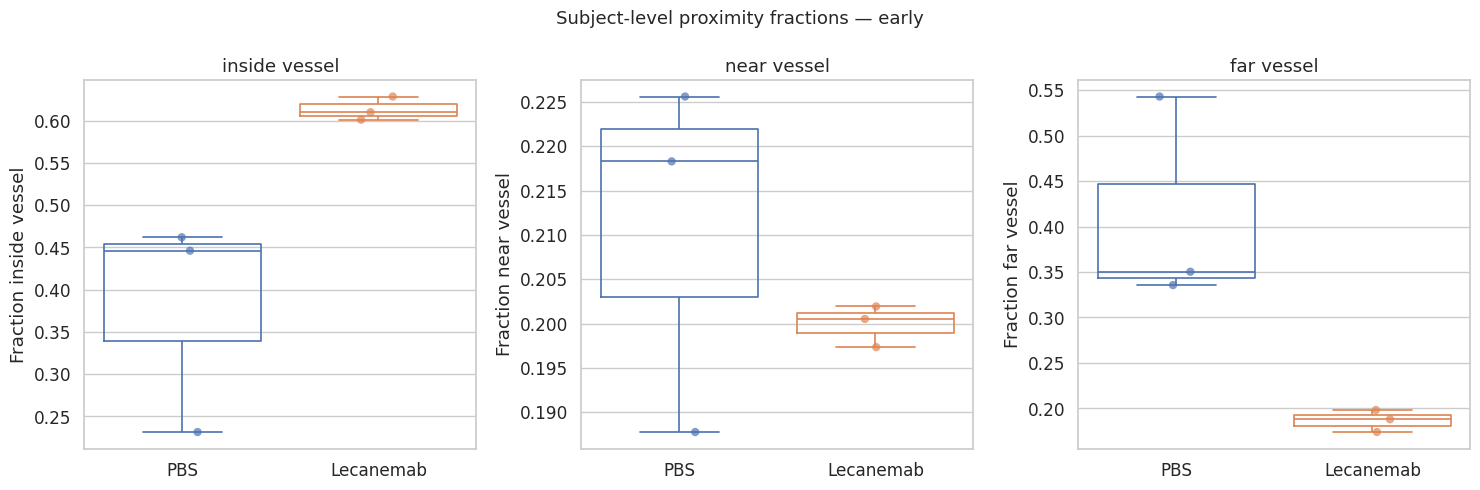


ANOVA (one-way) — proximity fractions — early
  frac_inside_vessel                   treat: p=0.035 *
  frac_near_vessel                     treat: p=0.414
  frac_far_vessel                      treat: p=0.029 *
  mean_sdt_um                          treat: p=0.032 *

Intravascular plaques: 238,190 (48.4%)


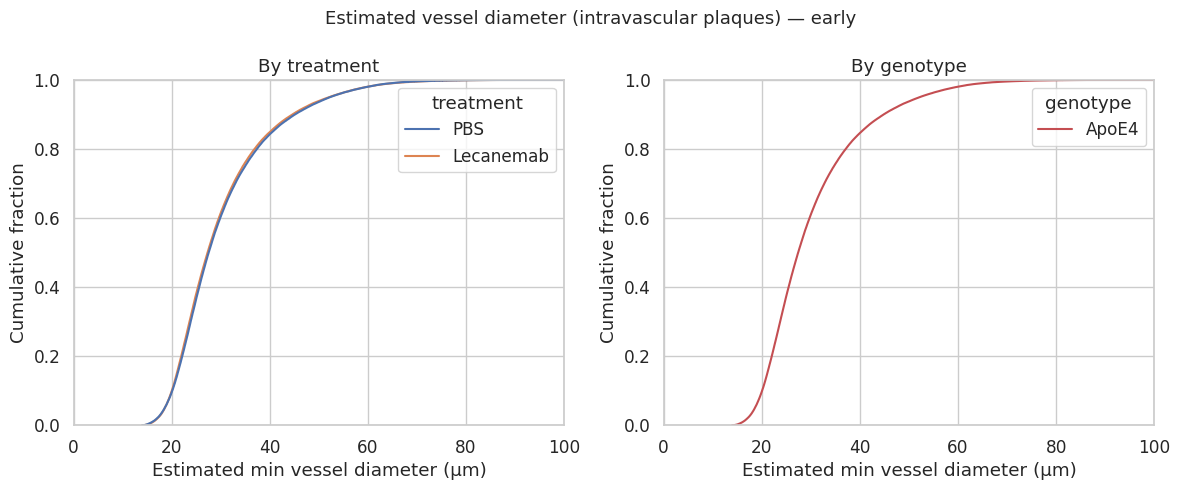

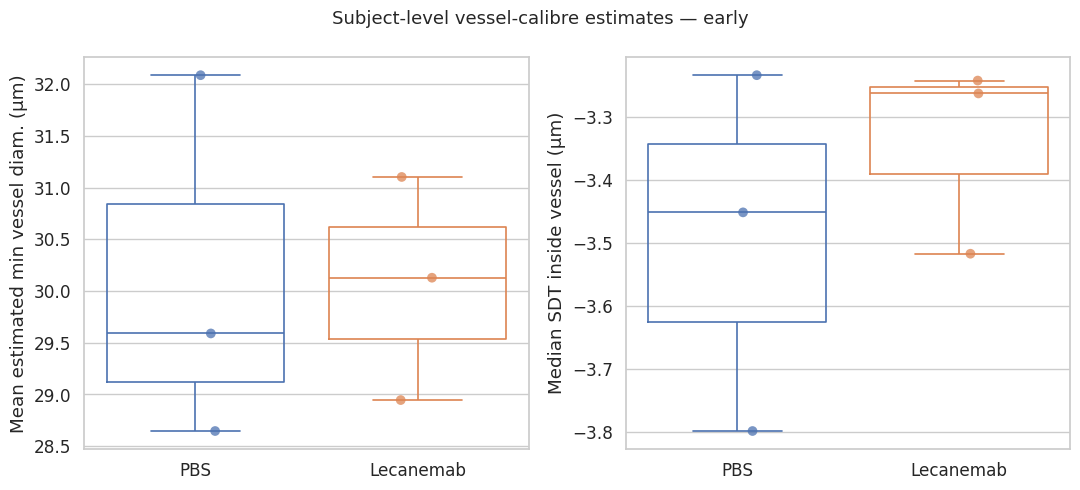


ANOVA (one-way) — vessel calibre metrics — early
  Mean estimated min vessel diam. (µm)           treat: p=0.970
  Median SDT inside vessel (µm)                  treat: p=0.456


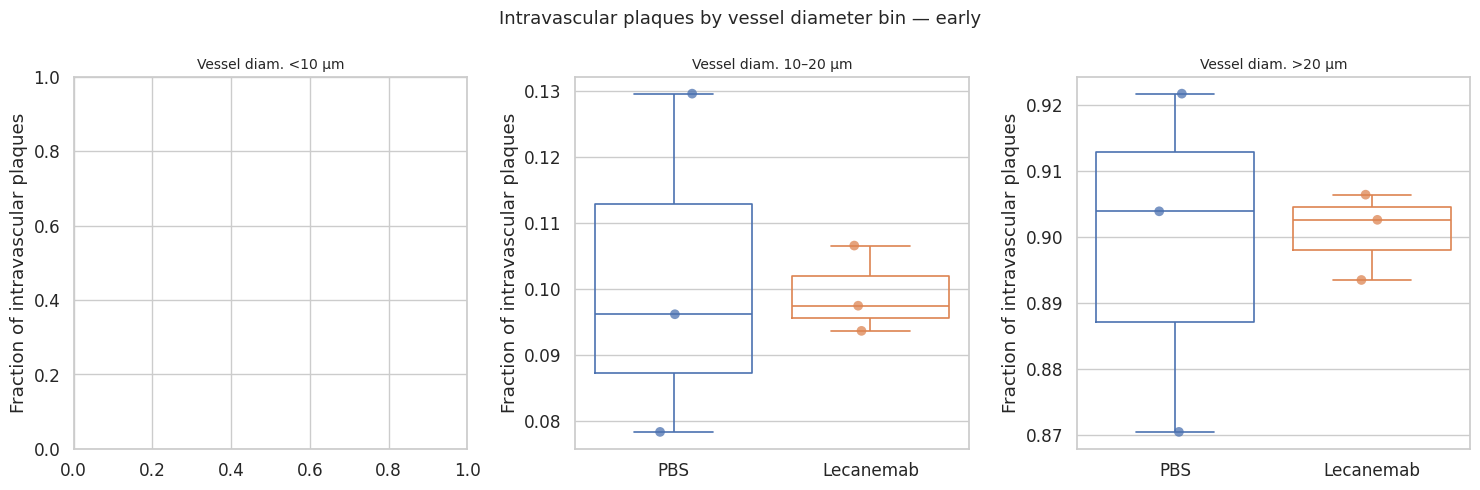

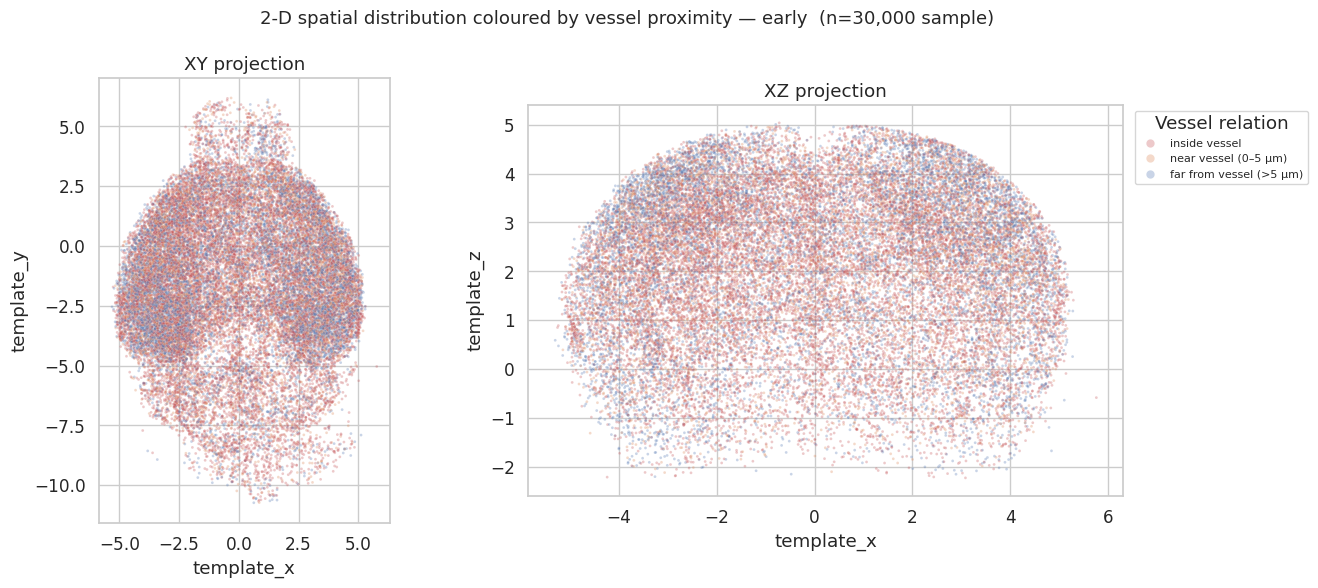


=== Dataset: late ===


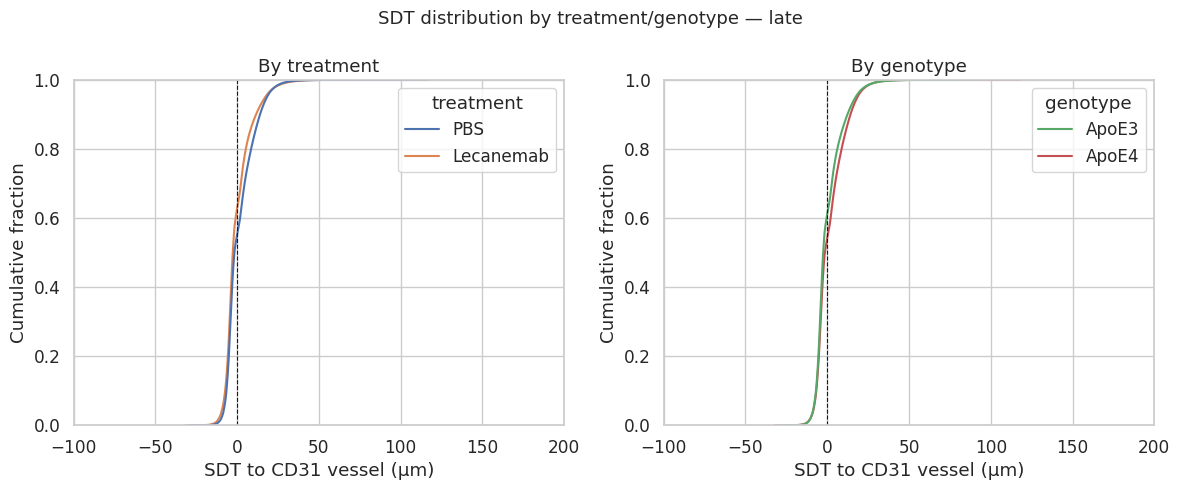

/localscratch/tmp/ipykernel_1540319/1905546179.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(groups, rotation=20, ha="right")


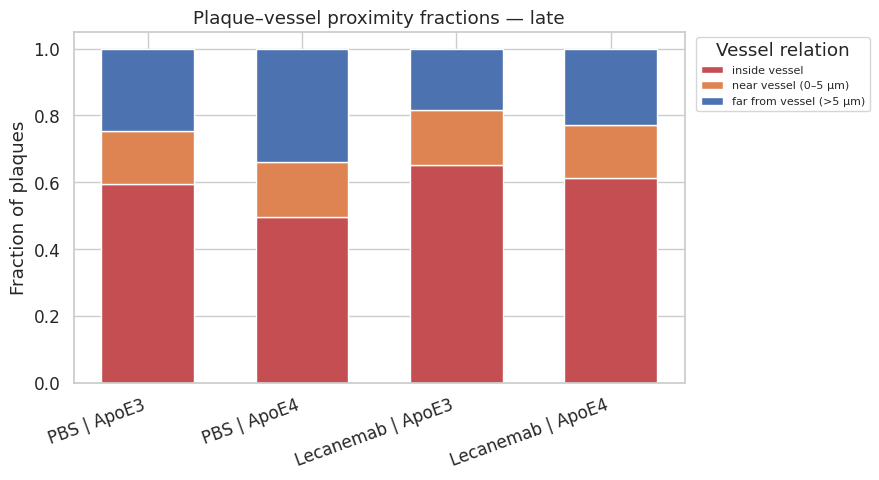

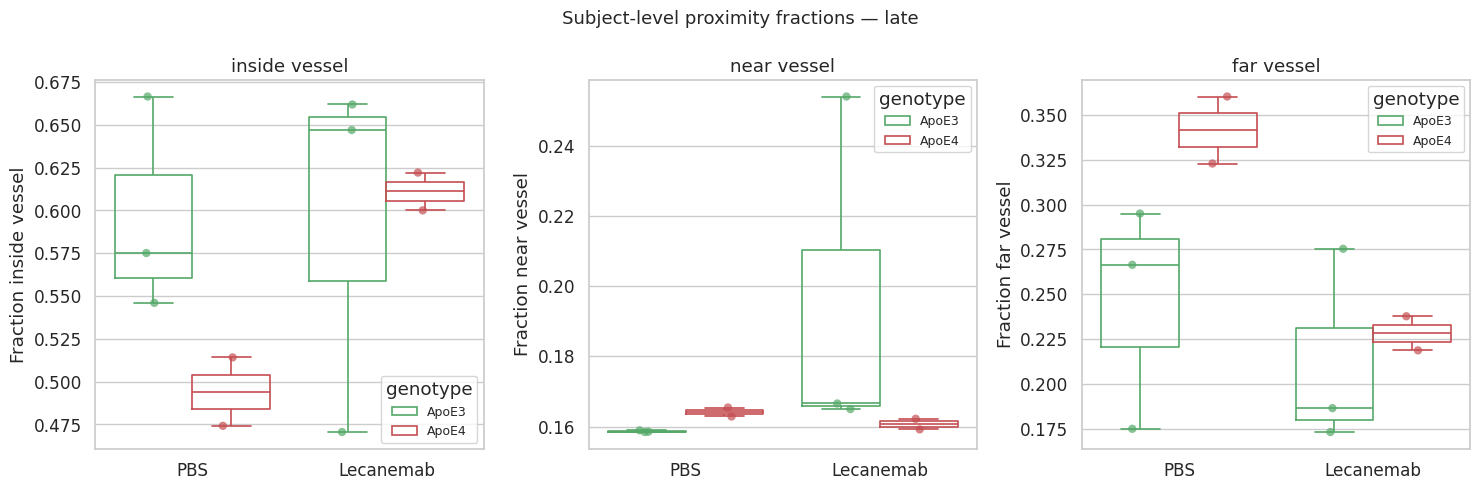


ANOVA (two-way) — proximity fractions — late
  frac_inside_vessel                   treat: p=0.364  geno: p=0.406  inter: p=0.249
  frac_near_vessel                     treat: p=0.312  geno: p=0.475  inter: p=0.333
  frac_far_vessel                      treat: p=0.083  geno: p=0.131  inter: p=0.263
  mean_sdt_um                          treat: p=0.046 *  geno: p=0.093  inter: p=0.368


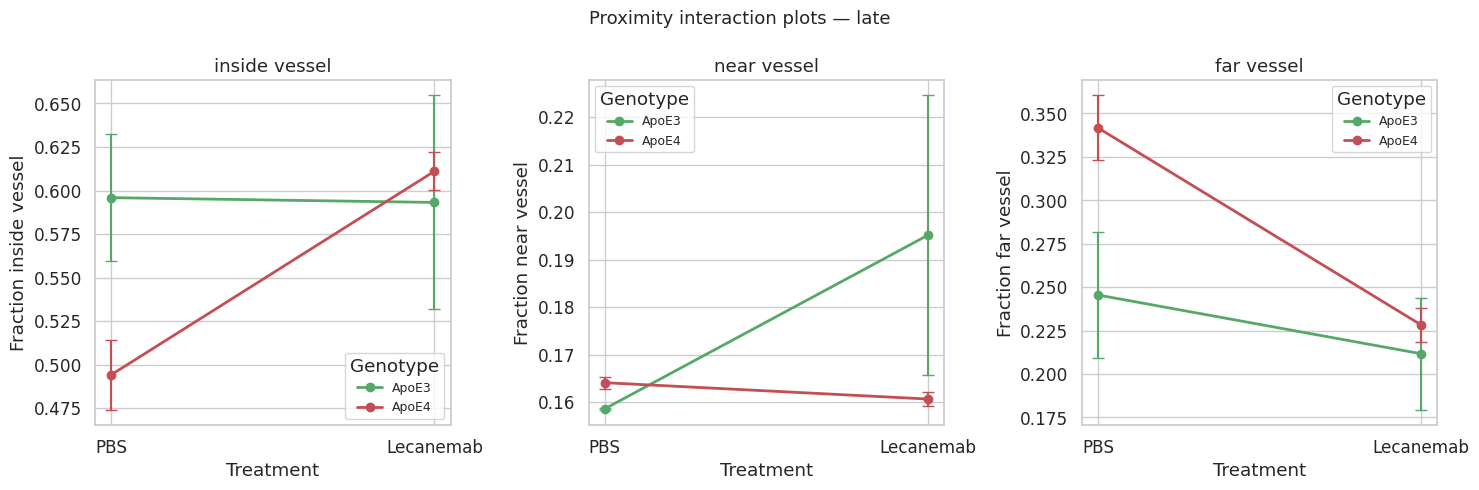


Intravascular plaques: 384,502 (57.8%)


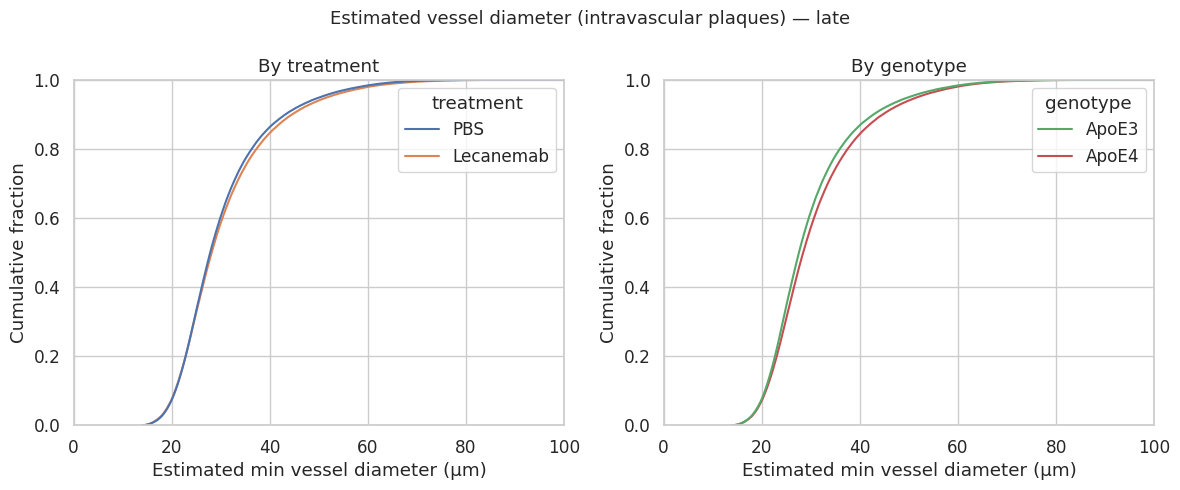

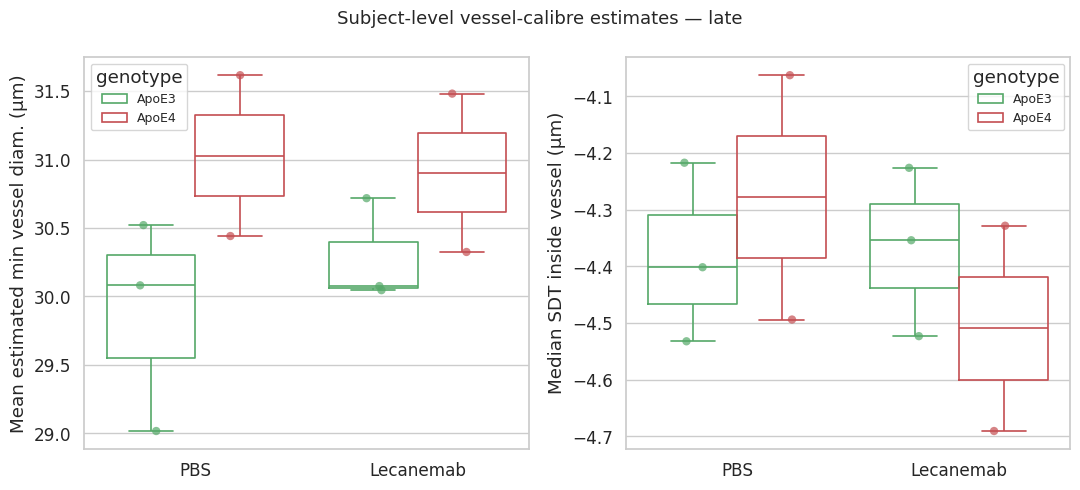


ANOVA (two-way) — vessel calibre metrics — late
  Mean estimated min vessel diam. (µm)           treat: p=0.672  geno: p=0.092  inter: p=0.571
  Median SDT inside vessel (µm)                  treat: p=0.547  geno: p=0.896  inter: p=0.387


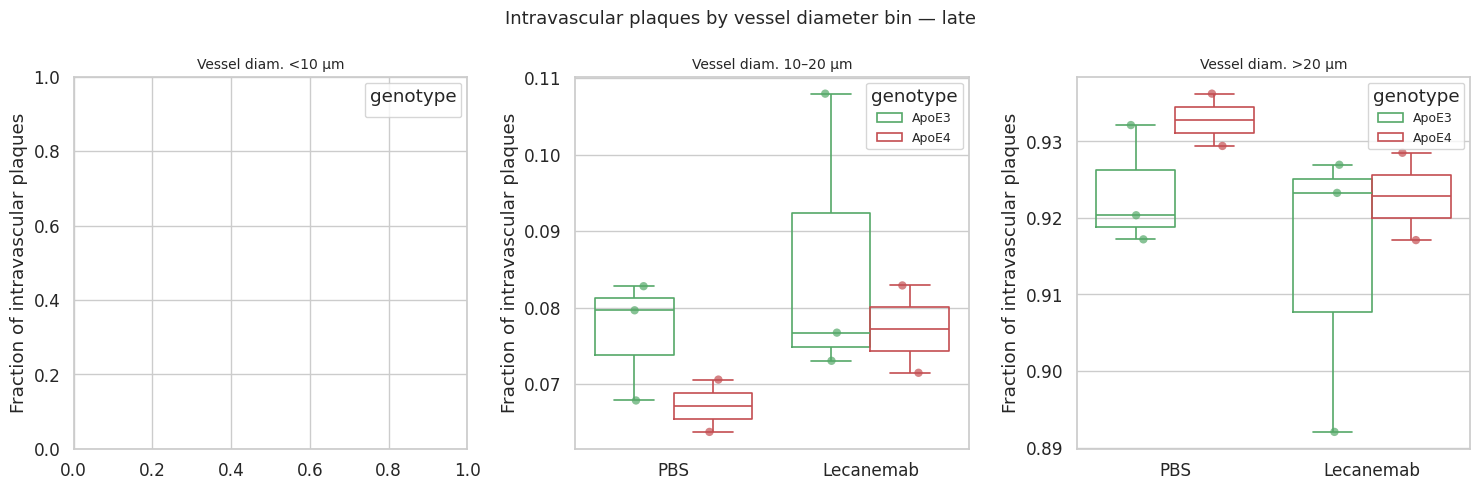

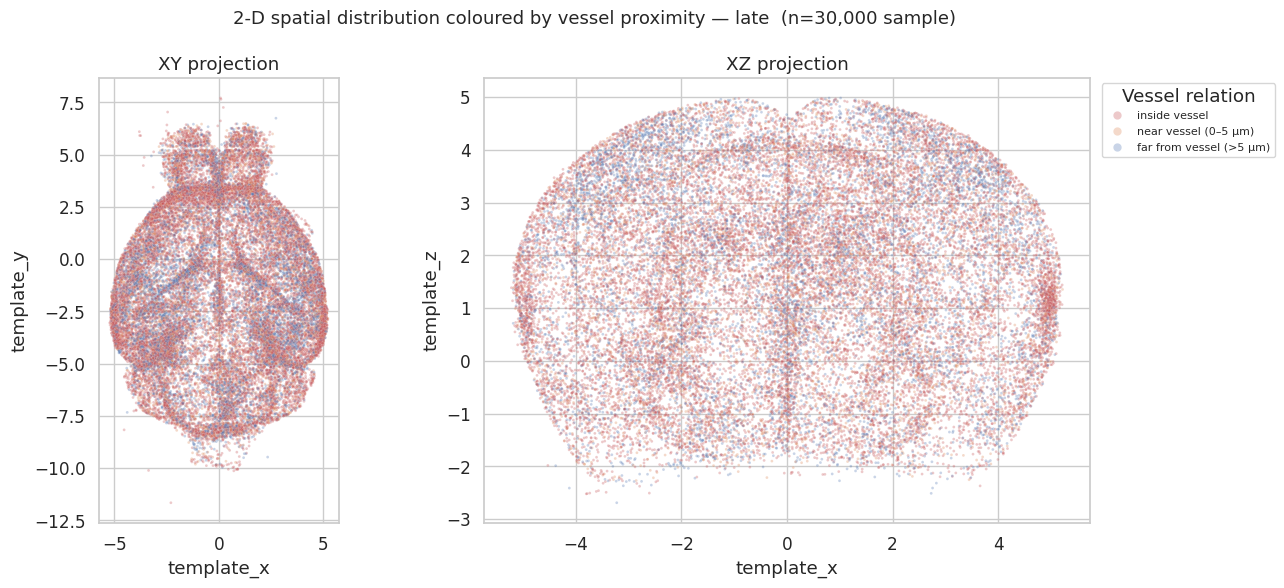

In [6]:
def run_vessel_analysis(name, df):
    """Run all vessel proximity analysis for one dataset."""
    df = df.loc[df["plaque_vol_ml"] <= VOL_THRESH_ML].copy()
    df["treatment"] = pd.Categorical(df["treatment"], categories=TREAT_ORDER, ordered=True)
    # Determine which genotypes are actually present in this dataset
    geno_present = [g for g in GENO_ORDER if (df["genotype"] == g).any()]
    df["genotype"] = pd.Categorical(df["genotype"], categories=geno_present, ordered=True)
    geno_palette  = {g: GENO_PALETTE[g] for g in geno_present}
    multi_geno = len(geno_present) > 1

    if "sdt_CD31_um" not in df.columns:
        df["sdt_CD31_um"] = df["sdt_CD31"] * 1000.0
    print(f"\n=== Dataset: {name} ===")

    # ── SDT ECDF ──────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (hue, order, palette) in zip(
        axes,
        [
            ("treatment", TREAT_ORDER,  TREAT_PALETTE),
            ("genotype",  geno_present, geno_palette),
        ],
    ):
        sns.ecdfplot(data=df, x="sdt_CD31_um", hue=hue,
                     hue_order=order, palette=palette, ax=ax)
        ax.set_xlabel("SDT to CD31 vessel (\u00b5m)")
        ax.set_ylabel("Cumulative fraction")
        ax.axvline(0, color="k", linewidth=0.8, linestyle="--")
        ax.set_xlim(-100, 200)
    axes[0].set_title("By treatment")
    axes[1].set_title("By genotype")
    fig.suptitle(f"SDT distribution by treatment/genotype \u2014 {name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"fig_{name}_sdt_ecdf.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── classify plaques ──────────────────────────────────────────────────
    df = classify_plaques(df)
    relation_categories = df["vessel_relation"].cat.categories.tolist()

    # ── stacked bar: proximity fractions by treatment × genotype ──────────
    prop_df = (
        df.groupby(["treatment", "genotype", "vessel_relation"], observed=True)
        .size()
        .rename("n")
        .reset_index()
    )
    prop_df["total"] = prop_df.groupby(["treatment", "genotype"],
                                        observed=True)["n"].transform("sum")
    prop_df["fraction"] = prop_df["n"] / prop_df["total"]
    prop_df["group"] = prop_df["treatment"].astype(str) + " | " + prop_df["genotype"].astype(str)

    PROX_PALETTE = {
        "inside vessel":                          "#C44E52",
        f"near vessel (0\u2013{TAU_UM:g} \u00b5m)": "#DD8452",
        f"far from vessel (>{TAU_UM:g} \u00b5m)": "#4C72B0",
    }

    groups = prop_df["group"].unique().tolist()
    bottoms = np.zeros(len(groups))
    fig, ax = plt.subplots(figsize=(9, 5))
    for cat in relation_categories:
        vals = [
            prop_df.loc[
                (prop_df["group"] == g) & (prop_df["vessel_relation"] == cat), "fraction"
            ].values[0]
            if len(prop_df.loc[
                (prop_df["group"] == g) & (prop_df["vessel_relation"] == cat)
            ]) > 0
            else 0.0
            for g in groups
        ]
        color = PROX_PALETTE.get(cat, "grey")
        ax.bar(groups, vals, bottom=bottoms, label=cat, color=color, width=0.6)
        bottoms += np.array(vals)
    ax.set_ylabel("Fraction of plaques")
    ax.set_xlabel("")
    ax.set_xticklabels(groups, rotation=20, ha="right")
    ax.legend(title="Vessel relation", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    ax.set_title(f"Plaque\u2013vessel proximity fractions \u2014 {name}")
    plt.tight_layout()
    plt.savefig(f"fig_{name}_proximity_fractions_stacked.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── subject-level proximity fractions & boxplots ──────────────────────
    subj_prox = subject_proximity_fractions(df)
    subj_prox["genotype"] = pd.Categorical(subj_prox["genotype"], categories=geno_present, ordered=True)
    prox_frac_cols = [c for c in subj_prox.columns if c.startswith("frac_")]

    fig, axes = plt.subplots(1, len(prox_frac_cols), figsize=(5 * len(prox_frac_cols), 5))
    if len(prox_frac_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, prox_frac_cols):
        label = col.replace("frac_", "").replace("_", " ")
        if multi_geno:
            boxstrip(ax, subj_prox, x="treatment", y=col, hue="genotype",
                     order=TREAT_ORDER, hue_order=geno_present, palette=geno_palette,
                     ylabel=f"Fraction {label}")
        else:
            sns.boxplot(data=subj_prox, x="treatment", y=col, order=TREAT_ORDER,
                        palette=TREAT_PALETTE, fill=False, linewidth=1.2, fliersize=0, ax=ax)
            sns.stripplot(data=subj_prox, x="treatment", y=col, order=TREAT_ORDER,
                          palette=TREAT_PALETTE, alpha=0.7, size=6, jitter=True, ax=ax)
            ax.set_ylabel(f"Fraction {label}")
        ax.set_xlabel("")
        ax.set_title(label)
    fig.suptitle(f"Subject-level proximity fractions \u2014 {name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"fig_{name}_proximity_fractions.png", dpi=150, bbox_inches="tight")
    plt.show()

    # mean SDT per subject
    subj_sdt = (
        df.groupby(["subject", "treatment", "genotype", "sex"], observed=True)["sdt_CD31_um"]
        .mean()
        .reset_index()
        .rename(columns={"sdt_CD31_um": "mean_sdt_um"})
    )
    subj_sdt["genotype"] = pd.Categorical(subj_sdt["genotype"], categories=geno_present, ordered=True)

    # ── ANOVA on proximity fractions ──────────────────────────────────────
    print(f"\nANOVA ({'two-way' if multi_geno else 'one-way'}) \u2014 proximity fractions \u2014 {name}")
    print("=" * 70)
    for col in [c for c in subj_prox.columns if c.startswith("frac_")] + ["mean_sdt_um"]:
        data = subj_prox if col != "mean_sdt_um" else subj_sdt
        if col not in data.columns:
            continue
        tbl = run_twoway_anova(data, col)
        p_treat = tbl.loc["C(treatment)", "PR(>F)"]
        p_geno  = tbl.loc["C(genotype)",  "PR(>F)"] if "C(genotype)" in tbl.index else float("nan")
        p_inter = tbl.loc["C(treatment):C(genotype)", "PR(>F)"] if "C(treatment):C(genotype)" in tbl.index else float("nan")
        def fmt_p(p): return f"p={p:.3f}" + (" *" if p < 0.05 else "") if not np.isnan(p) else "n/a"
        geno_str = f"  geno: {fmt_p(p_geno)}  inter: {fmt_p(p_inter)}" if multi_geno else ""
        print(f"  {col:<35}  treat: {fmt_p(p_treat)}{geno_str}")

    # ── interaction plots (only meaningful with multiple genotypes) ────────
    prox_int_cols = [c for c in subj_prox.columns if c.startswith("frac_")]
    if multi_geno and prox_int_cols:
        fig, axes = plt.subplots(1, len(prox_int_cols),
                                  figsize=(5 * len(prox_int_cols), 5))
        if len(prox_int_cols) == 1:
            axes = [axes]
        for ax, col in zip(axes, prox_int_cols):
            label = col.replace("frac_", "").replace("_", " ")
            agg = (
                subj_prox.groupby(["treatment", "genotype"], observed=True)[col]
                .agg(["mean", "sem"])
                .reset_index()
            )
            for geno, grp in agg.groupby("genotype", observed=True):
                color = GENO_PALETTE[geno]
                ax.plot(grp["treatment"].astype(str), grp["mean"],
                        marker="o", linewidth=2, color=color, label=geno)
                ax.errorbar(grp["treatment"].astype(str), grp["mean"],
                            yerr=grp["sem"], fmt="none", color=color, capsize=4)
            ax.set_ylabel(f"Fraction {label}")
            ax.set_xlabel("Treatment")
            ax.legend(title="Genotype", fontsize=9)
            ax.set_title(label)
        fig.suptitle(f"Proximity interaction plots \u2014 {name}", fontsize=13)
        plt.tight_layout()
        plt.savefig(f"fig_{name}_proximity_interaction.png", dpi=150, bbox_inches="tight")
        plt.show()

    # ── intravascular plaques: vessel-calibre estimation ──────────────────
    df_inside = df.loc[df["sdt_CD31_um"] < 0].copy()
    print(f"\nIntravascular plaques: {len(df_inside):,} "
          f"({100 * len(df_inside) / len(df):.1f}%)")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (hue, order, palette) in zip(
        axes,
        [
            ("treatment", TREAT_ORDER,  TREAT_PALETTE),
            ("genotype",  geno_present, geno_palette),
        ],
    ):
        sns.ecdfplot(data=df_inside, x="min_vessel_diam_um",
                     hue=hue, hue_order=order, palette=palette, ax=ax)
        ax.set_xlabel("Estimated min vessel diameter (\u00b5m)")
        ax.set_ylabel("Cumulative fraction")
        ax.set_xlim(0, 100)
    axes[0].set_title("By treatment")
    axes[1].set_title("By genotype")
    fig.suptitle(f"Estimated vessel diameter (intravascular plaques) \u2014 {name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"fig_{name}_vessel_calibre_ecdf.png", dpi=150, bbox_inches="tight")
    plt.show()

    # subject-level vessel calibre summaries
    subj_calibre = (
        df_inside
        .groupby(["subject", "treatment", "genotype", "sex"], observed=True)
        .agg(
            n_intravascular      =("min_vessel_diam_um", "size"),
            mean_min_diam_um     =("min_vessel_diam_um", "mean"),
            median_min_diam_um   =("min_vessel_diam_um", "median"),
            mean_sdt_inside_um   =("sdt_CD31_um",        "mean"),
            median_sdt_inside_um =("sdt_CD31_um",        "median"),
        )
        .reset_index()
    )
    subj_calibre["genotype"] = pd.Categorical(subj_calibre["genotype"], categories=geno_present, ordered=True)

    calibre_metrics = [
        ("mean_min_diam_um",   "Mean estimated min vessel diam. (\u00b5m)"),
        ("median_sdt_inside_um", "Median SDT inside vessel (\u00b5m)"),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for ax, (col, label) in zip(axes, calibre_metrics):
        if multi_geno:
            boxstrip(ax, subj_calibre, x="treatment", y=col, hue="genotype",
                     order=TREAT_ORDER, hue_order=geno_present, palette=geno_palette,
                     ylabel=label)
        else:
            sns.boxplot(data=subj_calibre, x="treatment", y=col, order=TREAT_ORDER,
                        palette=TREAT_PALETTE, fill=False, linewidth=1.2, fliersize=0, ax=ax)
            sns.stripplot(data=subj_calibre, x="treatment", y=col, order=TREAT_ORDER,
                          palette=TREAT_PALETTE, alpha=0.75, size=7, jitter=True, ax=ax)
            ax.set_ylabel(label)
        ax.set_xlabel("")
    fig.suptitle(f"Subject-level vessel-calibre estimates \u2014 {name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"fig_{name}_vessel_calibre_subject.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ANOVA on calibre
    print(f"\nANOVA ({'two-way' if multi_geno else 'one-way'}) \u2014 vessel calibre metrics \u2014 {name}")
    print("=" * 70)
    for col, label in calibre_metrics:
        tbl = run_twoway_anova(subj_calibre, col)
        p_treat = tbl.loc["C(treatment)", "PR(>F)"]
        p_geno  = tbl.loc["C(genotype)",  "PR(>F)"] if "C(genotype)" in tbl.index else float("nan")
        p_inter = tbl.loc["C(treatment):C(genotype)", "PR(>F)"] if "C(treatment):C(genotype)" in tbl.index else float("nan")
        def fmt_p(p): return f"p={p:.3f}" + (" *" if p < 0.05 else "") if not np.isnan(p) else "n/a"
        geno_str = f"  geno: {fmt_p(p_geno)}  inter: {fmt_p(p_inter)}" if multi_geno else ""
        print(f"  {label:<45}  treat: {fmt_p(p_treat)}{geno_str}")

    # vessel diameter bins
    def subject_vessel_diam_fractions(plaque_df,
                                       group_cols=("subject", "genotype", "treatment", "sex")):
        inside = plaque_df.loc[plaque_df["sdt_CD31_um"] < 0]
        counts = (
            inside.groupby(list(group_cols) + ["vessel_diam_bin"], observed=True)
            .size().rename("n").reset_index()
        )
        totals = (
            inside.groupby(list(group_cols), observed=True)
            .size().rename("n_total").reset_index()
        )
        out = counts.merge(totals, on=list(group_cols))
        out["fraction"] = out["n"] / out["n_total"]
        return out

    subj_diam = subject_vessel_diam_fractions(df)
    subj_diam["genotype"] = pd.Categorical(subj_diam["genotype"], categories=geno_present, ordered=True)
    diam_bins = df["vessel_diam_bin"].cat.categories.tolist()
    fig, axes = plt.subplots(1, len(diam_bins), figsize=(5 * len(diam_bins), 5))
    if len(diam_bins) == 1:
        axes = [axes]
    for ax, bin_label in zip(axes, diam_bins):
        bin_data = subj_diam.loc[subj_diam["vessel_diam_bin"] == bin_label]
        if multi_geno:
            boxstrip(ax, bin_data, x="treatment", y="fraction", hue="genotype",
                     order=TREAT_ORDER, hue_order=geno_present, palette=geno_palette,
                     ylabel="Fraction of intravascular plaques")
        else:
            sns.boxplot(data=bin_data, x="treatment", y="fraction", order=TREAT_ORDER,
                        palette=TREAT_PALETTE, fill=False, linewidth=1.2, fliersize=0, ax=ax)
            sns.stripplot(data=bin_data, x="treatment", y="fraction", order=TREAT_ORDER,
                          palette=TREAT_PALETTE, alpha=0.75, size=7, jitter=True, ax=ax)
            ax.set_ylabel("Fraction of intravascular plaques")
        ax.set_title(f"Vessel diam. {bin_label}", fontsize=10)
        ax.set_xlabel("")
    fig.suptitle(f"Intravascular plaques by vessel diameter bin \u2014 {name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"fig_{name}_vessel_diam_bins.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── 2-D spatial scatter ───────────────────────────────────────────────
    n_sample = 30_000
    sample = df.sample(min(n_sample, len(df)), random_state=42)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.scatterplot(
        data=sample, x="template_x", y="template_y",
        hue="vessel_relation", hue_order=relation_categories,
        palette=PROX_PALETTE, alpha=0.3, s=4, ax=axes[0],
    )
    axes[0].set_aspect("equal")
    axes[0].set_title("XY projection")
    axes[0].get_legend().remove()

    sns.scatterplot(
        data=sample, x="template_x", y="template_z",
        hue="vessel_relation", hue_order=relation_categories,
        palette=PROX_PALETTE, alpha=0.3, s=4, ax=axes[1],
    )
    axes[1].set_aspect("equal")
    axes[1].set_title("XZ projection")
    axes[1].legend(title="Vessel relation",
                   bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, markerscale=3)

    fig.suptitle(
        f"2-D spatial distribution coloured by vessel proximity \u2014 {name}"
        f"  (n={n_sample:,} sample)",
        fontsize=13,
    )
    plt.tight_layout()
    plt.savefig(f"fig_{name}_spatial_vessel_proximity.png", dpi=150, bbox_inches="tight")
    plt.show()


for name in DATASET_NAMES:
    df_raw = pd.read_parquet(f"data_{name}.parquet")
    run_vessel_analysis(name, df_raw)
